# 🧠 Training Your First Ensemble Model

## 🎯 Objective

In this assignment, you’ll evaluate the **ensemble model** you trained in **Module 5** (Random Forest or XGBoost) using appropriate **classification metrics**.

Your goal is to understand:
- What these numbers mean
- Where they fall short
- How they reflect the model’s usefulness

This is **not just about getting high scores**, but about **interpreting** what those scores reveal.

---

## 🧩 Assignment Instructions

### 📁 Load Your Previous Dataset

- Load your `additional_files/customer_churn_gold.csv` dataset
- Check for nulls, data types, and shapes  
- Split into features (`X`) and target (`y = Churn`)
- Store your results in variable `X` and `y`
---

In [1]:
import pandas as pd
import numpy as np 

### Please Write your answer here 

Delete the `raise NotImplementedError()` when you start writing your code.

#### This dataset is already processed in module 3 assignment and is being used here ####

In [2]:
# YOUR CODE HERE
df = pd.read_csv('customer_churn_gold.csv')
df.head()


,Unnamed: 0,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,MonthlyCharges,TotalCharges,TotalCharges_scaled,tenure_scaled,MonthlyCharges_scaled,Churn_encoded,PaymentMethod_encoded,tenure_years,long_contract,StreamingServices
0,0,5375.0,0.0,0,1.0,0.0,1,0.0,1.0,0.0,...,29.85,29.85,-0.992611,-1.277445,-1.160323,0.0,0.0,0.083333,0,0.0
1,1,3962.0,1.0,0,0.0,0.0,34,1.0,0.0,0.0,...,56.95,1889.50,-0.172165,0.066327,-0.259629,0.0,1.0,2.833333,1,0.0
2,2,2564.0,1.0,0,0.0,0.0,2,1.0,0.0,0.0,...,53.85,108.15,-0.958066,-1.236724,-0.362660,1.0,1.0,0.166667,0,0.0
3,3,5535.0,1.0,0,0.0,0.0,45,0.0,1.0,0.0,...,42.30,1840.75,-0.193672,0.514251,-0.746535,0.0,2.0,3.750000,1,0.0
4,4,6511.0,0.0,0,0.0,0.0,2,1.0,0.0,1.0,...,70.70,151.65,-0.938874,-1.236724,0.197365,1.0,0.0,0.166667,0,0.0


In [3]:
df = df[df.columns[1:]]

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,MonthlyCharges,TotalCharges,TotalCharges_scaled,tenure_scaled,MonthlyCharges_scaled,Churn_encoded,PaymentMethod_encoded,tenure_years,long_contract,StreamingServices
0,5375.0,0.0,0,1.0,0.0,1,0.0,1.0,0.0,0.0,...,29.85,29.85,-0.992611,-1.277445,-1.160323,0.0,0.0,0.083333,0,0.0
1,3962.0,1.0,0,0.0,0.0,34,1.0,0.0,0.0,2.0,...,56.95,1889.50,-0.172165,0.066327,-0.259629,0.0,1.0,2.833333,1,0.0
2,2564.0,1.0,0,0.0,0.0,2,1.0,0.0,0.0,2.0,...,53.85,108.15,-0.958066,-1.236724,-0.362660,1.0,1.0,0.166667,0,0.0
3,5535.0,1.0,0,0.0,0.0,45,0.0,1.0,0.0,2.0,...,42.30,1840.75,-0.193672,0.514251,-0.746535,0.0,2.0,3.750000,1,0.0
4,6511.0,0.0,0,0.0,0.0,2,1.0,0.0,1.0,0.0,...,70.70,151.65,-0.938874,-1.236724,0.197365,1.0,0.0,0.166667,0,0.0


In [5]:
X = df[[col for col in df.columns if col != 'Churn_encoded'] ]
y = df['Churn_encoded'].astype('int')

---
### Make sure to write your answer above this line
 -  Feel free to add as many code cells above this line as you wish    
 -  Make sure to save your answer in the variable named `X`, `y` respectively.
 -  If these variable are not found, you answer will be rejected by the system

## 📂 Loading your data

- Clean and transform your data.
    - Drop the `customerID` column
    - Convert `TotalCharges` to numeric (handles spaces or non-numeric values)
    - Convert target column `y` to binary values
    - Identify column types
    - Convert relevant columns using one hot encoding and fill in any missing values using `SimpleImputer`

Store your clean data into a variable named `X_cleaned`.
Your X_cleaned should be a numpy array that looks like this 

```python
([[  0.  ,   1.  ,  29.85, ...,   0.  ,   1.  ,   0.  ],
       [  0.  ,  34.  ,  56.95, ...,   0.  ,   0.  ,   1.  ],
       [  0.  ,   2.  ,  53.85, ...,   0.  ,   0.  ,   1.  ],
```

Hint :- Your `X_cleaned `should have an approximate shape of (7043, 45)

Overall, 
- Recreate the **features** and **target** used in your ensemble model from your `X` & `y`

In [6]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

### Please Write your answer here 

Delete the `raise NotImplementedError()` when you start writing your code.

In [7]:
# YOUR CODE HERE
X.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,PaperlessBilling,MonthlyCharges,TotalCharges,TotalCharges_scaled,tenure_scaled,MonthlyCharges_scaled,PaymentMethod_encoded,tenure_years,long_contract,StreamingServices
0,5375.0,0.0,0,1.0,0.0,1,0.0,1.0,0.0,0.0,...,1.0,29.85,29.85,-0.992611,-1.277445,-1.160323,0.0,0.083333,0,0.0
1,3962.0,1.0,0,0.0,0.0,34,1.0,0.0,0.0,2.0,...,0.0,56.95,1889.50,-0.172165,0.066327,-0.259629,1.0,2.833333,1,0.0
2,2564.0,1.0,0,0.0,0.0,2,1.0,0.0,0.0,2.0,...,1.0,53.85,108.15,-0.958066,-1.236724,-0.362660,1.0,0.166667,0,0.0
3,5535.0,1.0,0,0.0,0.0,45,0.0,1.0,0.0,2.0,...,0.0,42.30,1840.75,-0.193672,0.514251,-0.746535,2.0,3.750000,1,0.0
4,6511.0,0.0,0,0.0,0.0,2,1.0,0.0,1.0,0.0,...,1.0,70.70,151.65,-0.938874,-1.236724,0.197365,0.0,0.166667,0,0.0


In [8]:
X_cleaned = X.drop('customerID', axis = 1)

In [9]:
X_cleaned.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PaperlessBilling,MonthlyCharges,TotalCharges,TotalCharges_scaled,tenure_scaled,MonthlyCharges_scaled,PaymentMethod_encoded,tenure_years,long_contract,StreamingServices
0,0.0,0,1.0,0.0,1,0.0,1.0,0.0,0.0,2.0,...,1.0,29.85,29.85,-0.992611,-1.277445,-1.160323,0.0,0.083333,0,0.0
1,1.0,0,0.0,0.0,34,1.0,0.0,0.0,2.0,0.0,...,0.0,56.95,1889.50,-0.172165,0.066327,-0.259629,1.0,2.833333,1,0.0
2,1.0,0,0.0,0.0,2,1.0,0.0,0.0,2.0,2.0,...,1.0,53.85,108.15,-0.958066,-1.236724,-0.362660,1.0,0.166667,0,0.0
3,1.0,0,0.0,0.0,45,0.0,1.0,0.0,2.0,0.0,...,0.0,42.30,1840.75,-0.193672,0.514251,-0.746535,2.0,3.750000,1,0.0
4,0.0,0,0.0,0.0,2,1.0,0.0,1.0,0.0,0.0,...,1.0,70.70,151.65,-0.938874,-1.236724,0.197365,0.0,0.166667,0,0.0


In [10]:
y.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn_encoded, dtype: int64

---
### Make sure to write your answer above this line
 -  Feel free to add as many code cells above this line as you wish    
 -  Make sure to save your answer in the variable named `X_cleaned` respectively.
 -  If these variable are not found, you answer will be rejected by the system

## 📂 Splitting your data
Now that we have cleaned our data. 
- Time to split our data into train and test sets,
- Go for a 75/25 split or anything near that. 
- Store your answer in the variable named `X_train`, `X_test`, `y_train`, `y_test` respectively

In [11]:
from sklearn.model_selection import train_test_split

### Please Write your answer here 

Delete the `raise NotImplementedError()` when you start writing your code.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y, test_size = 0.25, stratify = y, random_state = 42)

In [13]:
X_train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PaperlessBilling,MonthlyCharges,TotalCharges,TotalCharges_scaled,tenure_scaled,MonthlyCharges_scaled,PaymentMethod_encoded,tenure_years,long_contract,StreamingServices
6661,0.0,0,1.0,1.0,72,0.0,1.0,0.0,0.0,2.0,...,0.0,53.65,3784.00,0.663656,1.613701,-0.369308,3.0,6.000000,1,4.0
4811,0.0,0,0.0,0.0,4,1.0,0.0,0.0,0.0,0.0,...,1.0,46.00,193.60,-0.920367,-1.155283,-0.623562,1.0,0.333333,0,0.0
2193,1.0,0,0.0,1.0,56,1.0,0.0,2.0,1.0,1.0,...,1.0,21.20,1238.65,-0.459309,0.962175,-1.447814,1.0,4.666667,1,2.0
1904,1.0,0,0.0,0.0,56,1.0,2.0,1.0,0.0,2.0,...,1.0,94.45,5124.60,1.255106,0.962175,0.986719,0.0,4.666667,1,2.0
6667,0.0,0,0.0,0.0,9,1.0,0.0,1.0,0.0,0.0,...,1.0,79.55,723.40,-0.686628,-0.951682,0.491503,0.0,0.750000,0,2.0


In [14]:
y_train.value_counts() / y_train.sum()

Churn_encoded
0    2.767475
1    1.000000
Name: count, dtype: float64

In [15]:
y_test.value_counts() /y_test.sum()

Churn_encoded
0    2.770878
1    1.000000
Name: count, dtype: float64

---
### Make sure to write your answer above this line
 -  Feel free to add as many code cells above this line as you wish    
 -  Make sure to save your answer in the variable named `X_train`, `X_test`, `y_train`, `y_test` respectively.
 -  If these variable are not found, you answer will be rejected by the system

### 📁 Load Your Previous Model

- Now that we have our `X_train`, `X_test`, `y_train` & `y_test`. We can start training our models
- Reload or retrain the same **model** from Module 5(Random Forest or XGBoost) with your training data.
- Pick any model(Random Forest or XGBoost) and store your model in a variable named `model`
---

In [16]:
from sklearn.ensemble import RandomForestClassifier

### Please Write your answer here 

Delete the `raise NotImplementedError()` when you start writing your code.

In [17]:
# YOUR CODE HERE
model = RandomForestClassifier(
    n_estimators=500,
    max_depth=8,          # try: 5, 10, 15, None
    min_samples_split=5,     # try: 2, 5, 10
    min_samples_leaf=2,      # try: 1, 2, 4
    max_features="sqrt",     # try: "sqrt", "log2", 0.5
    class_weight="balanced", # useful if churners are fewer
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_featu

---
### Make sure to write your answer above this line
 -  Feel free to add as many code cells above this line as you wish    
 -  Make sure to save your answer in the variable named `model` respectively.
 -  If these variable are not found, you answer will be rejected by the system

# **✏️ Write:**
- 1 sentence confirming the model and data are loaded correctly

## Make sure to write the answer below this cell

- The model and data are loaded correctly. 

# 🔮 Generate Predictions

- Use `.predict()` to generate predictions on your **test set**
- Store your predictions for the training data in a variable named `train_preds`
- Store your predictions for the testing data in a variable named `test_preds`
---

### Please Write your answer here 

Delete the `raise NotImplementedError()` when you start writing your code.

In [18]:
# YOUR CODE HERE
train_preds = model.predict(X_train)
test_preds = model.predict(X_test)

---
### Make sure to write your answer above this line
 -  Feel free to add as many code cells above this line as you wish    
 -  Make sure to save your answer in the variable named `train_preds` & `test_preds` respectively.
 -  If these variable are not found, you answer will be rejected by the system

### 🧮 Calculate These Metrics

Calculate the following **classification metrics**:

| **Metric**  | **What it Measures**                                           |
|-------------|----------------------------------------------------------------|
| Accuracy    | Overall % of predictions that were correct                     |
| Precision   | Among predicted churns, how many were actually churned?        |
| Recall      | Among actual churns, how many did the model identify?          |
| F1 Score    | Harmonic mean of precision and recall                          |


Do so for both the `training` and `test` set. 
- Store your results in variables named `train_acc` & `test_acc` for `accuracy_score`.
- Store your results in variables named `train_precision` & `test_precision` for `precision_score`.
- Store your results in variables named `train_recall` & `test_recall` for `recall_score`.
- Store your results in variables named `train_f1` & `test_f1` for `f1_score`.

---

In [19]:
# Accuracy
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

### Please Write your answer here 

Delete the `raise NotImplementedError()` when you start writing your code.

In [20]:
# YOUR CODE HERE
train_acc = accuracy_score(y_train, train_preds)
test_acc = accuracy_score(y_test, test_preds)

print(train_acc, test_acc)

0.821469140477092 0.768313458262351


In [21]:
train_precision = precision_score(y_train, train_preds)
test_precision = precision_score(y_test, test_preds)

print(train_precision, test_precision)

0.6115702479338843 0.5438335809806835


In [22]:
train_recall = recall_score(y_train, train_preds)
test_recall = recall_score(y_test, test_preds)

print(train_recall, test_recall)

0.8972895863052782 0.7837259100642399


In [23]:
train_f1 = f1_score(y_train, train_preds)
test_f1 = f1_score(y_test, test_preds)

print(train_f1, test_f1)

0.7273778548713501 0.6421052631578947


In [24]:
print("Accuracy of train and test: ", train_acc, test_acc)
print("Precision of train and test: ", train_precision, test_precision)
print("Recall of train and test: ", train_recall, test_recall)
print("F1 Score of train and test: ", train_f1, test_f1)

Accuracy of train and test:  0.821469140477092 0.768313458262351
Precision of train and test:  0.6115702479338843 0.5438335809806835
Recall of train and test:  0.8972895863052782 0.7837259100642399
F1 Score of train and test:  0.7273778548713501 0.6421052631578947


In [25]:
# Stratified 5-fold cross-validation to check the metrics are stable
# (not just an artifact of one lucky train/test split).
from sklearn.model_selection import StratifiedKFold, cross_validate

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'average_precision', 'roc_auc']
cv_results = cross_validate(model, X_cleaned, y, cv=skf, scoring=scoring, n_jobs=-1)

print("Stratified 5-fold CV (mean +/- std):")
for s in scoring:
    fold_scores = cv_results['test_' + s]
    print(f"  {s:18s}: {fold_scores.mean():.4f} +/- {fold_scores.std():.4f}")

/private/tmp/claude-501/-Users-mohan-Downloads-Machine-Learning-customer-churn-api/5a16ae61-f805-4bed-bdc8-7e1449a37887/scratchpad/churn_venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/private/tmp/claude-501/-Users-mohan-Downloads-Machine-Learning-customer-churn-api/5a16ae61-f805-4bed-bdc8-7e1449a37887/scratchpad/churn_venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/private/tmp/claude-501/-Users-mohan-Downloads-Machine-Learning-customer-churn-api/5a16ae61-f805-4bed-bdc8-7e1449a37887/scratchpad/churn_venv/li

/private/tmp/claude-501/-Users-mohan-Downloads-Machine-Learning-customer-churn-api/5a16ae61-f805-4bed-bdc8-7e1449a37887/scratchpad/churn_venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/private/tmp/claude-501/-Users-mohan-Downloads-Machine-Learning-customer-churn-api/5a16ae61-f805-4bed-bdc8-7e1449a37887/scratchpad/churn_venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/private/tmp/claude-501/-Users-mohan-Downloads-Machine-Learning-customer-churn-api/5a16ae61-f805-4bed-bdc8-7e1449a37887/scratchpad/churn_venv/li

/private/tmp/claude-501/-Users-mohan-Downloads-Machine-Learning-customer-churn-api/5a16ae61-f805-4bed-bdc8-7e1449a37887/scratchpad/churn_venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/private/tmp/claude-501/-Users-mohan-Downloads-Machine-Learning-customer-churn-api/5a16ae61-f805-4bed-bdc8-7e1449a37887/scratchpad/churn_venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/private/tmp/claude-501/-Users-mohan-Downloads-Machine-Learning-customer-churn-api/5a16ae61-f805-4bed-bdc8-7e1449a37887/scratchpad/churn_venv/li

/private/tmp/claude-501/-Users-mohan-Downloads-Machine-Learning-customer-churn-api/5a16ae61-f805-4bed-bdc8-7e1449a37887/scratchpad/churn_venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/private/tmp/claude-501/-Users-mohan-Downloads-Machine-Learning-customer-churn-api/5a16ae61-f805-4bed-bdc8-7e1449a37887/scratchpad/churn_venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/private/tmp/claude-501/-Users-mohan-Downloads-Machine-Learning-customer-churn-api/5a16ae61-f805-4bed-bdc8-7e1449a37887/scratchpad/churn_venv/li

/private/tmp/claude-501/-Users-mohan-Downloads-Machine-Learning-customer-churn-api/5a16ae61-f805-4bed-bdc8-7e1449a37887/scratchpad/churn_venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/private/tmp/claude-501/-Users-mohan-Downloads-Machine-Learning-customer-churn-api/5a16ae61-f805-4bed-bdc8-7e1449a37887/scratchpad/churn_venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/private/tmp/claude-501/-Users-mohan-Downloads-Machine-Learning-customer-churn-api/5a16ae61-f805-4bed-bdc8-7e1449a37887/scratchpad/churn_venv/li

/private/tmp/claude-501/-Users-mohan-Downloads-Machine-Learning-customer-churn-api/5a16ae61-f805-4bed-bdc8-7e1449a37887/scratchpad/churn_venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/private/tmp/claude-501/-Users-mohan-Downloads-Machine-Learning-customer-churn-api/5a16ae61-f805-4bed-bdc8-7e1449a37887/scratchpad/churn_venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/private/tmp/claude-501/-Users-mohan-Downloads-Machine-Learning-customer-churn-api/5a16ae61-f805-4bed-bdc8-7e1449a37887/scratchpad/churn_venv/li

/private/tmp/claude-501/-Users-mohan-Downloads-Machine-Learning-customer-churn-api/5a16ae61-f805-4bed-bdc8-7e1449a37887/scratchpad/churn_venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/private/tmp/claude-501/-Users-mohan-Downloads-Machine-Learning-customer-churn-api/5a16ae61-f805-4bed-bdc8-7e1449a37887/scratchpad/churn_venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/private/tmp/claude-501/-Users-mohan-Downloads-Machine-Learning-customer-churn-api/5a16ae61-f805-4bed-bdc8-7e1449a37887/scratchpad/churn_venv/li

Stratified 5-fold CV (mean +/- std):
  accuracy          : 0.7635 +/- 0.0093
  precision         : 0.5379 +/- 0.0127
  recall            : 0.7731 +/- 0.0141
  f1                : 0.6344 +/- 0.0127
  average_precision : 0.6601 +/- 0.0259
  roc_auc           : 0.8456 +/- 0.0114


/private/tmp/claude-501/-Users-mohan-Downloads-Machine-Learning-customer-churn-api/5a16ae61-f805-4bed-bdc8-7e1449a37887/scratchpad/churn_venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/private/tmp/claude-501/-Users-mohan-Downloads-Machine-Learning-customer-churn-api/5a16ae61-f805-4bed-bdc8-7e1449a37887/scratchpad/churn_venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/private/tmp/claude-501/-Users-mohan-Downloads-Machine-Learning-customer-churn-api/5a16ae61-f805-4bed-bdc8-7e1449a37887/scratchpad/churn_venv/li

---
### Make sure to write your answer above this line
 -  Feel free to add as many code cells above this line as you wish    
 -  Make sure to save your answer in the variable named 
    - `train_acc` & `test_acc`
    - `train_precision` & `test_precision`
    - `train_recall` & `test_recall`
    - `train_f1` & `test_f1` 
 -  If these variable are not found, you answer will be rejected by the system

### 🧠 Interpret the Results

For **each metric** you calculated:

**✏️ Write (1–2 sentences per metric):**
- What does this metric tell you in the context of **customer churn**?
- Is the score **good enough** for a business use-case? Why or why not?
- Are there any **trade-offs** shown between precision and recall?
- What does the **confusion matrix** reveal about where your model succeeds or struggles?

---

## Make sure to write the answer below this cell

- The customer churn model has decent accuracy (~77%). After using `class_weight='balanced'`, the recall is now around 78% on the test data. This tells us that the model is able to detect about 78% of churned customers. The trade-off is that precision drops to ~54%, so many customers it flags as churn do not actually churn.
- For recall, the score is now good enough to be useful. Recall is the most costliest metric in this business usecase, and at ~78% it is far more reliable than the earlier ~50%. Precision is still weak though, so the flagged list will contain a lot of false alarms.
- Yes. Precision and recall measure exactly the opposite metrics: false positives and false negatives respectively. Here we have deliberately traded precision for recall.
- The confusion metrics gives a granular view on how many of the predictions are false in predicting churn or no churn. Helping us understand what might be going wrong.

### 📉 Visualize the Confusion Matrix

Use a **visualization** to display the confusion matrix:

```python
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()
```
---

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

### Please Write your answer here 

Delete the `raise NotImplementedError()` when you start writing your code.

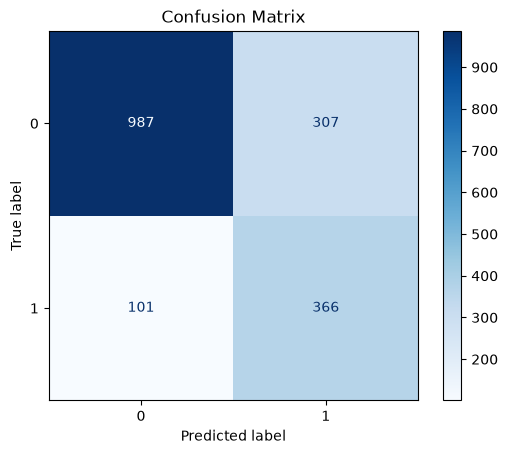

In [27]:
# YOUR CODE HERE
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

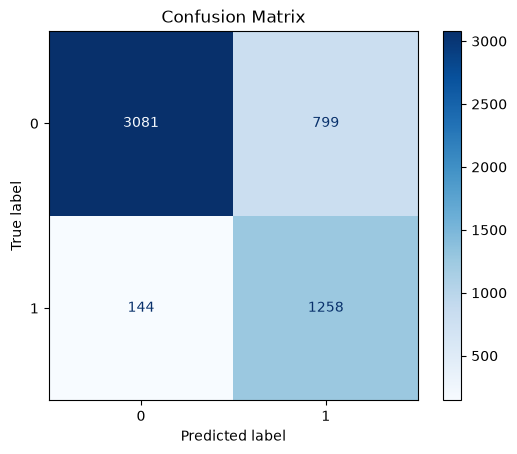

In [28]:
ConfusionMatrixDisplay.from_estimator(model, X_train, y_train, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

---
### Make sure to write your answer above this line
 -  Feel free to add as many code cells above this line as you wish    

# **✏️ Write (2–4 sentences):**

- What kind of **mistakes** is your model making?
- Which type of **error** (false positives or false negatives) might be more **costly for the business**, and why?

## Make sure to write the answer below this cell

- After balancing the classes, the model is no longer biased towards no-churn — if anything it now leans towards predicting churn, which shows up as a lot of false positives (precision is only ~54%).
- False negatives are more costly for the business. It means that the model is unable to predict the customer who is about to leave, which is really costly for the business. This is exactly why we accept more false positives (lower precision) in order to push recall up and miss fewer churners.

### 💡 Recommendation

# **✏️ Write:**

- If you were presenting this to a **non-technical stakeholder**, which **one metric** would you highlight and **why**?

---

## Make sure to write the answer below this cell

- I would highlight the recall of the model. Which means that I am emphasizing on predicting whether a customer will leave. 

# 📝 Summary

**✏️ Write (2–3 sentences):**

- Is this a **useful model** for predicting churn?
- What would be your **next step** to improve it?

---

## Make sure to write the answer below this cell

- This model is reasonably useful for predicting churn — recall is around 78%, and 5-fold cross-validation confirms it is stable (recall 0.77 +/- 0.01), so the number is not just a lucky split. The main weakness is precision (~54%).
- My next steps: tune the classification threshold instead of using the default 0.5, so I can trade precision and recall towards a business target; calibrate the predicted probabilities; and compare against a properly class-balanced XGBoost.

## ✅ Deliverables Checklist

- [ ] Model loaded and test predictions generated  
- [ ] All four metrics (`accuracy`, `precision`, `recall`, `f1`) calculated  
- [ ] Each metric clearly interpreted  
- [ ] Confusion matrix (visual or table) included and described  
- [ ] Recommendation with regards to business relevance  
- [ ] Summary about model usefulness and next steps


---

<h2><center> Completing your test </center></h2>

- Once you have completed your test and answered all the questions:
  
- You can open the guide using the button located on the far right of your screen.

- The button will look like this image:  
  ![](additional_files/End_guide_button.png)

- Clicking on this button will allow you to mark the test as complete using the button shown below:  
  ![](additional_files/completion_button.png)

- Please click on **Mark as Completed** to end and submit your test.

- Thank you!
